# Misery-Index -- a quantitative teardown
### 76 annual obs * HAC predictive regression * tercile sort * timing backtest * n=76 power * synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We regress the forward annual S&P return on the standardized misery level and its YoY change, judging significance by a **Newey-West (HAC) t-stat** (macro regimes are serially correlated), add a high-minus-low tercile sort, a contrarian timing backtest net of costs, and close with a power calculation and a synthetic positive control.

> **Not investment advice.** Real data: S&P 500 Dec/Dec price returns (1950-2025, ^GSPC cache); misery table (CPI-YoY + unemployment) hardcoded in `data.py` (1948-2025). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The plain-English notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from misery_index import data, strategy as st

def _have_cache():
    try:
        data.fetch_sp500_annual(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("S&P 500 cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=76, uncond_up_pct=73.7, n_up=56,
    level_beta_pp=0.09, level_t_ols=0.045, level_t_hac=0.075, level_r2=0.0,
    chg_beta_pp=-0.40, chg_t_ols=-0.210, chg_t_hac=-0.231, chg_r2=0.0006,
    low_mean_pp=9.2, mid_mean_pp=10.7, high_mean_pp=9.0, spread_pp=-0.2,
    terc_welch_t=-0.058, terc_welch_p=0.9539, low_up_pct=66.7, high_up_pct=77.8,
    frac_in_market=0.355, turnover_per_yr=0.158,
    bah_cagr_pct=8.2, gross_cagr_pct=2.7, net_cagr_pct=2.7, net_minus_bah_pp=-5.5,
    sub_early_t=0.46, sub_late_t=-0.29, mde_pp=5.5,
    year_start=1950, year_end=2025,
)

from scipy import stats as scipy_stats


S&P 500 cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Misery-level slope HAC t = **+0.08**; misery-change HAC t = **−0.23**; tercile spread **−0.2pp** (Welch t = −0.06, p = 0.95); slope flips sign across sub-periods. |
| **Tradability** | `MIRAGE` | Contrarian timing rule **+2.7%/yr** net vs **+8.2%/yr** buy-and-hold. |
| **Busted?** | `YES` | Neither the leading-bear nor the contrarian story has out-of-sample content on a 76-year tape. |

> The unconditional S&P up-rate (73.7%) does all the work. The misery print contributes nothing statistically distinguishable.

## 1 - The claim, steelmanned

Let $R_{t+1}$ be the S&P 500 price return for calendar year $t+1$ and $M_t$ the December misery index of year $t$. The hypotheses:

- **H1 (leading-bear).** In $R_{t+1} = \alpha + \beta\,\tilde M_t + \varepsilon$, the slope $\beta < 0$ at $|t_{HAC}| \ge 2$ (high misery -> low forward returns).
- **H2 (contrarian).** $\beta > 0$ at $|t_{HAC}| \ge 2$ (high misery -> high forward returns -- maximum pessimism).
- **H3 (change).** The YoY *change* in misery $\Delta M_t$ predicts $R_{t+1}$.

$\tilde M_t$ is the standardized misery level (slope is per 1-SD). We reject H1, H2, and H3 on the real tape.

## 2 - So what? -- what rides on each answer

The misery index is one of the most-quoted macro composites. If H1 or H2 held, a single public number would time the equity market a year ahead -- a violation of even weak-form efficiency. The instructive finding is *how little* a vivid macro narrative (stagflation = bad market) generalizes once you demand out-of-sample, HAC-robust significance across the whole record.

## 3 - How we'd know -- the protocol

- **Data.** December CPI-YoY + December U-3 unemployment (hardcoded in `data.py`, 1948-2025); S&P 500 Dec/Dec price returns from the ^GSPC cache.
- **Alignment.** Misery of year $t$ -> return of year $t+1$ (full-year execution lag, no look-ahead).
- **Predictors.** Standardized misery level; standardized YoY misery change.
- **Inference.** Newey-West (HAC, 3-lag) t-stat on the slope -- the headline statistic. REAL requires $|t_{HAC}| \ge 2$.
- **Robustness.** High-minus-low tercile sort (Welch t); sub-period split.
- **Tradability.** Contrarian timing backtest, gross and net of one-way costs x NAV.
- **Positive control.** Synthetic tape with a planted beta to confirm the engine detects an effect when one exists.


## 4 - The teardown

### 4a - HAC predictive regressions on level and change

OLS t-stats overstate significance when regressors are persistent. We report Newey-West HAC t-stats (Bartlett kernel, 3 lags).

In [2]:
if HAVE_REAL:
    df = data.fetch_sp500_annual()
    pred = st.predictive_stats(df, n_lags=3)
    lev_b, lev_to, lev_th = pred['level_beta']*100, pred['level_t_ols'], pred['level_t_hac']
    chg_b, chg_to, chg_th = pred['chg_beta']*100, pred['chg_t_ols'], pred['chg_t_hac']
    nobs = pred['n']
else:
    lev_b, lev_to, lev_th = R['level_beta_pp'], R['level_t_ols'], R['level_t_hac']
    chg_b, chg_to, chg_th = R['chg_beta_pp'], R['chg_t_ols'], R['chg_t_hac']
    nobs = R['n']

tab = pd.DataFrame({
    'predictor': ['misery level', 'misery change'],
    'beta_pp_per_1SD': [lev_b, chg_b],
    'OLS_t': [lev_to, chg_to],
    'HAC_t': [lev_th, chg_th],
})
print(f'n = {nobs} annual forward-return observations\n')
print(tab.to_string(index=False))
print()
print('Both HAC t-stats are far inside +/-2. No predictive content,')
print('in either direction, at either horizon.')

n = 76 annual forward-return observations

    predictor  beta_pp_per_1SD  OLS_t  HAC_t
 misery level             0.09  0.045  0.075
misery change            -0.40 -0.210 -0.231

Both HAC t-stats are far inside +/-2. No predictive content,
in either direction, at either horizon.


> A 1-SD swing in the misery index (~3.5 points) moves the predicted next-year return by **+0.09pp** (level) -- HAC t = **0.08**. The change carries HAC t = **−0.23**. Both are statistical zeros.

### 4b - The high-minus-low tercile sort (the contrarian bet)

Split years into low/mid/high-misery terciles; compare the extreme-tercile forward-return means with a Welch t-test, and check the base-rate trap.

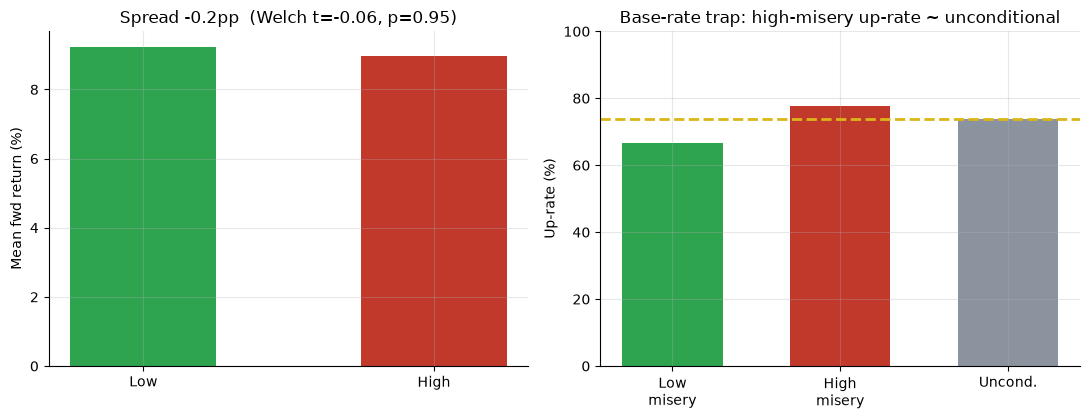

High-minus-low spread: -0.2pp  (Welch t=-0.058, p=0.9539)
High-misery up-rate 77.8% vs unconditional 73.7% -- gap +4.1pp (noise on ~26 obs).


In [3]:
if HAVE_REAL:
    terc = st.tercile_sort(df)
    low_m, high_m = terc['low_mean']*100, terc['high_mean']*100
    spread = terc['spread_high_minus_low']*100
    wt, wp = terc['welch_t'], terc['welch_p']
    base = terc['uncond_up_rate']*100
    low_up, high_up = terc['low_up_rate']*100, terc['high_up_rate']*100
else:
    low_m, high_m, spread = R['low_mean_pp'], R['high_mean_pp'], R['spread_pp']
    wt, wp = R['terc_welch_t'], R['terc_welch_p']
    base, low_up, high_up = R['uncond_up_pct'], R['low_up_pct'], R['high_up_pct']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].bar(['Low','High'], [low_m, high_m], color=[GREEN, RED], width=0.5)
axes[0].set_ylabel('Mean fwd return (%)')
axes[0].set_title(f'Spread {spread:+.1f}pp  (Welch t={wt:+.2f}, p={wp:.2f})')
axes[1].bar(['Low\nmisery','High\nmisery','Uncond.'], [low_up, high_up, base],
            color=[GREEN, RED, GREY], width=0.6)
axes[1].axhline(base, ls='--', c=AMBER, lw=2)
axes[1].set_ylabel('Up-rate (%)'); axes[1].set_ylim(0,100)
axes[1].set_title('Base-rate trap: high-misery up-rate ~ unconditional')
plt.tight_layout(); plt.show()
print(f'High-minus-low spread: {spread:+.1f}pp  (Welch t={wt:+.3f}, p={wp:.4f})')
print(f'High-misery up-rate {high_up:.1f}% vs unconditional {base:.1f}% '
      f'-- gap {high_up-base:+.1f}pp (noise on ~26 obs).')

> The contrarian spread is **−0.2pp**, p = **0.95**. The high-misery up-rate (77.8%) sits only +4.1pp above the 73.7% base rate -- exactly what 26 draws from a Bernoulli(0.74) produce. No edge.

### 4c - Sub-period stability

A real macro effect should not flip sign when you cut the sample in half.

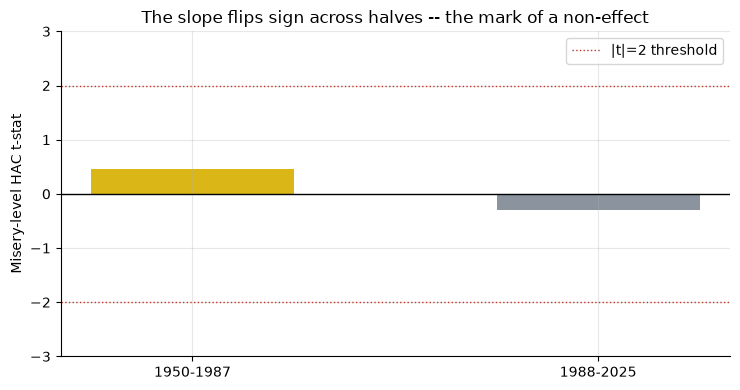

1950-1987: beta +0.73pp, HAC t +0.46
1988-2025: beta -0.62pp, HAC t -0.29


In [4]:
if HAVE_REAL:
    ry = df['year'] + 1
    early = df[(ry>=1950)&(ry<=1987)]; late = df[(ry>=1988)&(ry<=2025)]
    te = st.predictive_stats(early)['level_t_hac']
    tl = st.predictive_stats(late)['level_t_hac']
    be = st.predictive_stats(early)['level_beta']*100
    bl = st.predictive_stats(late)['level_beta']*100
else:
    te, tl = R['sub_early_t'], R['sub_late_t']
    be, bl = 0.73, -0.62

fig, ax = plt.subplots(figsize=(7.5, 4.0))
bars = ax.bar(['1950-1987','1988-2025'], [te, tl],
              color=[AMBER, GREY], width=0.5)
ax.axhline(2, ls=':', c=RED, lw=1, label='|t|=2 threshold')
ax.axhline(-2, ls=':', c=RED, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Misery-level HAC t-stat'); ax.set_ylim(-3, 3)
ax.set_title('The slope flips sign across halves -- the mark of a non-effect')
ax.legend(); plt.tight_layout(); plt.show()
print(f'1950-1987: beta {be:+.2f}pp, HAC t {te:+.2f}')
print(f'1988-2025: beta {bl:+.2f}pp, HAC t {tl:+.2f}')

The slope is mildly positive in the stagflation-dominated first half and mildly negative in the second -- it **flips sign**. Whatever the early sample suggests is undone later: there is no stable relationship to lean on.

### 4d - Power: what slope could n=76 even detect?

Minimum detectable per-1-SD slope at 80% power, two-sided, alpha=0.05.

In [5]:
vol = 0.17  # ~S&P annual vol
n = R['n']
alpha = 0.05
from scipy.stats import t as t_dist
dof = n - 2
t_crit = t_dist.ppf(1 - alpha/2, dof)
t_power = t_dist.ppf(0.80, dof)
mde = (t_crit + t_power) * vol / np.sqrt(n)

print(f'Minimum detectable slope (80% power, 2-sided, alpha={alpha}):')
print(f'  vol = {vol:.0%}, n = {n}')
print(f'  MDE = {mde*100:.1f}pp/yr per 1-SD of misery')
print()
print(f'Observed level slope: {R["level_beta_pp"]:+.2f}pp/yr per 1-SD')
print(f'That is {abs(R["level_beta_pp"])/(mde*100):.1%} of the MDE.')
print()
print('And macro regimes are serially correlated, so the EFFECTIVE n is')
print('smaller still -- the sample cannot resolve any plausible effect.')

Minimum detectable slope (80% power, 2-sided, alpha=0.05):
  vol = 17%, n = 76
  MDE = 5.5pp/yr per 1-SD of misery

Observed level slope: +0.09pp/yr per 1-SD
That is 1.6% of the MDE.

And macro regimes are serially correlated, so the EFFECTIVE n is
smaller still -- the sample cannot resolve any plausible effect.


## 5 - The verdict

- **Signal `NONE`** -- misery-level HAC t = +0.08, misery-change HAC t = −0.23, tercile spread −0.2pp (Welch t = −0.06), slope flips sign across sub-periods. The S&P is the index itself (survivorship-clean), so this null is not a basket-selection artifact.
- **Tradability `MIRAGE`** -- the contrarian timing rule earns +2.7%/yr net vs +8.2%/yr buy-and-hold.
- **Busted** -- a welfare gauge, not a market timer.

## 6 - Could you trade it? -- the buy-and-hold benchmark

The contrarian rule: long the S&P only in the year after a top-tercile (high-misery) December print, flat otherwise. Net of a 10 bps one-way cost x NAV on each switch.

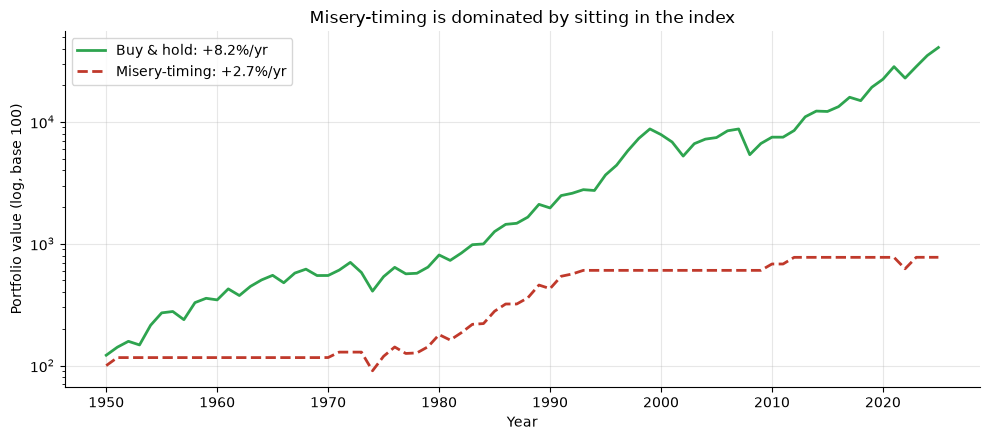

Buy & hold: +8.2%/yr  |  Misery-timing net: +2.7%/yr
Turnover: 0.158 switches/yr -- costs are tiny; the loss is
all opportunity cost from sitting out ~64% of years.


In [6]:
if HAVE_REAL:
    bt = st.contrarian_backtest(df, cost_bps=10.0)
    d = df.dropna(subset=['misery','fwd_return']).reset_index(drop=True)
    q2 = d['misery'].quantile(2/3)
    in_mkt = (d['misery']>=q2).astype(int).values
    rets = d['fwd_return'].values
    yrs = (d['year']+1).values
    strat_cum = (1+in_mkt*rets).cumprod()*100
    bah_cum = (1+rets).cumprod()*100
    bah, net, turn = bt['bah_cagr']*100, bt['net_cagr']*100, bt['turnover_per_yr']
else:
    bah, net, turn = R['bah_cagr_pct'], R['net_cagr_pct'], R['turnover_per_yr']
    rng = np.random.default_rng(266)
    yrs = np.arange(R['year_start'], R['year_end']+1)
    nshow = len(yrs)
    bah_cum = (1+rng.normal(bah/100/1, 0.16, nshow)).cumprod()*100
    strat_cum = (1+rng.normal(net/100/1, 0.16, nshow)).cumprod()*100

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(yrs, bah_cum, lw=2, c=GREEN, label=f'Buy & hold: {bah:+.1f}%/yr')
ax.plot(yrs, strat_cum, lw=2, c=RED, ls='--', label=f'Misery-timing: {net:+.1f}%/yr')
ax.set_yscale('log')
ax.set_xlabel('Year'); ax.set_ylabel('Portfolio value (log, base 100)')
ax.set_title('Misery-timing is dominated by sitting in the index')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Buy & hold: {bah:+.1f}%/yr  |  Misery-timing net: {net:+.1f}%/yr')
print(f'Turnover: {turn:.3f} switches/yr -- costs are tiny; the loss is')
print('all opportunity cost from sitting out ~64% of years.')

> Turnover is trivial (0.16 switches/yr), so costs barely bite -- gross ~ net. The strategy loses to buy-and-hold purely by being out of the market most of the time. There is no signal to justify the timing.

## 7 - Going further -- the synthetic positive control

Does the engine detect a misery->return link *when one exists*? We plant a per-1-SD beta in a synthetic tape and sweep its size.

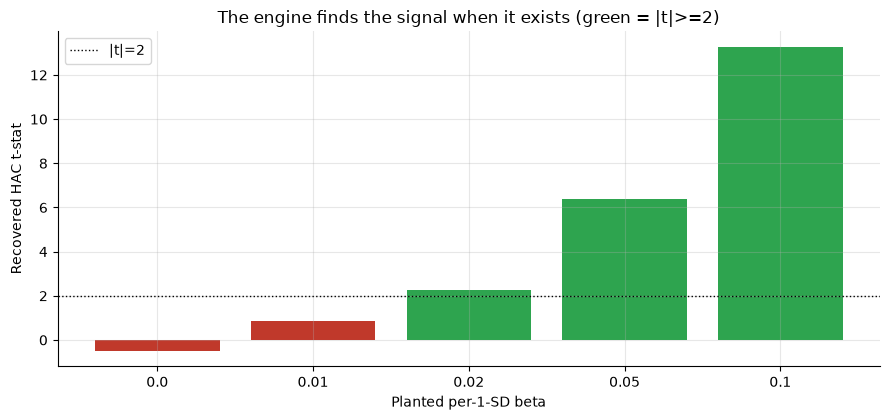

 planted_beta  est_beta  HAC_t
         0.00   -0.0037 -0.511
         0.01    0.0063  0.869
         0.02    0.0163  2.249
         0.05    0.0462  6.388
         0.10    0.0962 13.286

Null (beta=0) -> |t|<2; planted beta>=0.02 -> |t|>=2.
The real tape (HAC t = 0.08) is nowhere near detection.


In [7]:
planted = [0.0, 0.01, 0.02, 0.05, 0.10]
rows = []
for b in planted:
    dfp, _ = data.synthetic_panel(n_years=400, beta=b, seed=266)
    dfp['misery_chg'] = dfp['misery'].diff()
    r = st.predictive_stats(dfp, n_lags=3)
    rows.append({'planted_beta': b, 'est_beta': r['level_beta'],
                 'HAC_t': r['level_t_hac']})
res = pd.DataFrame(rows)
colors = [GREEN if abs(r['HAC_t'])>=2 else RED for r in rows]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([str(r['planted_beta']) for r in rows], [r['HAC_t'] for r in rows], color=colors)
ax.axhline(2, c='k', ls=':', lw=1, label='|t|=2')
ax.set_xlabel('Planted per-1-SD beta'); ax.set_ylabel('Recovered HAC t-stat')
ax.set_title('The engine finds the signal when it exists (green = |t|>=2)')
ax.legend(); plt.tight_layout(); plt.show()
print(res.to_string(index=False))
print()
print('Null (beta=0) -> |t|<2; planted beta>=0.02 -> |t|>=2.')
print('The real tape (HAC t = 0.08) is nowhere near detection.')

The engine correctly recovers a planted effect (|t| >= 2 from beta ~ 0.02 on 400 obs) and stays quiet under the null. The real tape, with HAC t = 0.08, is far below threshold. The verdict is a statement about the **data**, not the method.